# Interaction Force Data - Descriptive Statistics and Raw Plots

Stats and raw plots for the "Interaction Forces During Walking" chapter: mean/min/max of the
converted handle forces, forward-velocity profiles, and the raw $F_x$-$F_z$ point clouds for
the three walking conditions.

Notation follows the thesis and `stability_analysis.m`:
- $F_x$: horizontal handle force, positive from handle toward user (opposing travel)
- $F_z$: vertical handle force, positive downward
- Raw data is in kgf, converted to N via $\times g$
- Raw columns are `Fx` (lateral), `Fy` (forward), `Fz` (downward) per support (UFES email
  convention). Thesis sign convention: $F_{x,\text{thesis}} = -(F_{y,\text{left}} +
  F_{y,\text{right}})$, $F_z = F_{z,\text{left}} + F_{z,\text{right}}$ (both supports summed).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

g = 9.81  # m/s^2, matches rollator_dynamics.m / average_curves.m

# six raw CSVs live in "Interaction Force Measured Data", next to this notebook
DATA_DIR = Path("Interaction Force Measured Data")

CONDITIONS = {
    1: {
        "label": "Condition 1: constant velocity 0.2 m/s",
        "short": "Const. vel.",
        "force_file": "walker_straight_1_constvel-0.2ms_force.csv",
        "velocity_file": "walker_straight_1_constvel-0.2ms_velocity.csv",
    },
    2: {
        "label": "Condition 2: admittance, $d_v$=20, $d_w$=10",
        "short": "Adm. dv=20",
        "force_file": "walker_straight_2_adm-dv20-dw10_force.csv",
        "velocity_file": "walker_straight_2_adm-dv20-dw10_velocity.csv",
    },
    3: {
        "label": "Condition 3: admittance, $d_v$=200, $d_w$=100",
        "short": "Adm. dv=200",
        "force_file": "walker_straight_3_adm-dv200-dw100_force.csv",
        "velocity_file": "walker_straight_3_adm-dv200-dw100_velocity.csv",
    },
}


## Load raw data

Force data comes in kgf; column names follow the UFES convention (`Fx`=lateral, `Fy`=forward, `Fz`=downward, per support).


In [2]:
def load_condition(cond):
    # load force + velocity csvs for one condition, attach thesis-convention columns
    force = pd.read_csv(DATA_DIR / cond["force_file"])
    velocity = pd.read_csv(DATA_DIR / cond["velocity_file"])

    # kgf -> N, both supports summed, thesis sign convention
    force["Fz_total_N"] = (force["Fz_left"] + force["Fz_right"]) * g
    force["Fx_thesis_N"] = -(force["Fy_left"] + force["Fy_right"]) * g

    # per-support forward force in N, kept around for the 40 N check further down
    force["Fy_left_N"] = force["Fy_left"] * g
    force["Fy_right_N"] = force["Fy_right"] * g

    return force, velocity

data = {}
for cond_id, cond in CONDITIONS.items():
    force_df, vel_df = load_condition(cond)
    data[cond_id] = {"force": force_df, "velocity": vel_df, **cond}
    print(f"Condition {cond_id}: {len(force_df)} force samples, {len(vel_df)} velocity samples, "
          f"duration {vel_df['t_s'].iloc[-1]:.1f} s")


Condition 1: 15410 force samples, 15411 velocity samples, duration 154.1 s
Condition 2: 9534 force samples, 9534 velocity samples, duration 95.3 s
Condition 3: 17579 force samples, 17579 velocity samples, duration 175.8 s


## Sampling frequency

$\Delta t$ between consecutive `t_s` values, for each of the six raw files (3 conditions x
{force, velocity}), reported as mean/std/min/max, with $f_s = 1/\overline{\Delta t}$. Force
and velocity can come from different sensor paths so the rates are checked separately here
rather than assumed to match - these measured numbers are what "100 Hz" actually refers to
elsewhere in the analysis.


In [3]:
# dt between consecutive t_s samples, per raw file, and the derived rate fs = 1 / mean(dt)
fs_rows = []
for cond_id, cond in CONDITIONS.items():
    for kind, fname in (("force", cond["force_file"]), ("velocity", cond["velocity_file"])):
        t = pd.read_csv(DATA_DIR / fname)["t_s"].to_numpy()
        dt = np.diff(t)
        fs_rows.append({
            "file": fname,
            "condition": cond_id,
            "signal": kind,
            "n_samples": len(t),
            "dt_mean_s": dt.mean(),
            "dt_std_s": dt.std(),
            "dt_min_s": dt.min(),
            "dt_max_s": dt.max(),
            "fs_Hz": 1.0 / dt.mean(),
        })

sampling_df = pd.DataFrame(fs_rows).set_index("file")

# force vs velocity rate agreement within each condition
for cond_id in CONDITIONS:
    sub = sampling_df[sampling_df["condition"] == cond_id]
    f_hz = sub.loc[sub["signal"] == "force", "fs_Hz"].iloc[0]
    v_hz = sub.loc[sub["signal"] == "velocity", "fs_Hz"].iloc[0]
    print(f"Condition {cond_id}: force {f_hz:.3f} Hz vs velocity {v_hz:.3f} Hz "
          f"(difference {abs(f_hz - v_hz):.4f} Hz)")

sampling_df.round({"dt_mean_s": 6, "dt_std_s": 6, "dt_min_s": 6, "dt_max_s": 6, "fs_Hz": 3})


Condition 1: force 100.011 Hz vs velocity 100.012 Hz (difference 0.0008 Hz)
Condition 2: force 100.016 Hz vs velocity 100.016 Hz (difference 0.0006 Hz)
Condition 3: force 100.009 Hz vs velocity 100.010 Hz (difference 0.0010 Hz)


,condition,signal,n_samples,dt_mean_s,dt_std_s,dt_min_s,dt_max_s,fs_Hz
file,,,,,,,,
walker_straight_1_constvel-0.2ms_force.csv,1,force,15410,0.009999,0.000165,0.009042,0.010952,100.011
walker_straight_1_constvel-0.2ms_velocity.csv,1,velocity,15411,0.009999,0.000189,0.009010,0.010993,100.012
walker_straight_2_adm-dv20-dw10_force.csv,2,force,9534,0.009998,0.000185,0.009027,0.010923,100.016
walker_straight_2_adm-dv20-dw10_velocity.csv,2,velocity,9534,0.009998,0.000183,0.009055,0.010929,100.016
walker_straight_3_adm-dv200-dw100_force.csv,3,force,17579,0.009999,0.000178,0.009066,0.010929,100.009
walker_straight_3_adm-dv200-dw100_velocity.csv,3,velocity,17579,0.009999,0.000178,0.008985,0.011002,100.010


Force and velocity agree to better than 0.01 Hz within every condition (all six files sit
at 100.0 Hz, $\Delta t$ jitter around 0.0002 s), so even though they come from different
sensor paths they share a common 100 Hz time base in practice. The 100 Hz figure used
elsewhere is measured here, not assumed.


## Raw velocity validation

Checked before the velocity data gets summarized or differentiated: completeness, monotonic
timestamps, a plausible $v_x$ range, and whether $v_x$ looks like a raw sensor sample or
something already pre-differentiated. That last point is checked two ways: the fraction of
samples taking a *distinct* $v_x$ value (low = signal only visits a small set of levels), and
how well those levels fit a single uniform grid (`max_grid_resid_%`, the largest deviation of
any level from an integer multiple of the modal step, as a percentage of that step). Both
computed directly on the raw column, no rounding first.

Backs this thesis paragraph (Data Overview):

> Before computing descriptive statistics, the raw velocity data were
> validated: no missing values were found, timestamps were strictly
> increasing, and $v_x$ remained within a physically reasonable range for
> walking-paced use. The signal was further checked for whether it resembled a
> raw sensor sample or a pre-differentiated quantity: across the three
> conditions only $0.7$-$3.4\%$ of samples took distinct values, and every
> observed value of $v_x$ lies on a uniform grid with a step of approximately
> $1$~mm/s. This quantization is consistent with a signal derived from discrete
> encoder counts rather than a smoothly computed derivative. It motivates the
> filtering applied in the following section: differentiating $v_x$ directly to
> obtain acceleration would amplify this quantization noise rather than recover
> a physically meaningful signal, so the raw data is filtered first.


In [4]:
# Validation of the raw VELOCITY data, before descriptive stats and before the
# differentiation done in the filtering notebook. Checks: completeness, strictly
# increasing timestamps, plausible v_x range, and how quantized v_x is (distinct-value
# fraction, modal step, how well the levels fit a uniform grid).
WALK_VX_BOUND = 2.0  # m/s, generous upper bound for walker-paced forward speed

val_rows = []
for cond_id, d in data.items():
    v = d["velocity"]
    vx = v["vx"].to_numpy()
    t = v["t_s"].to_numpy()
    n = len(v)

    # distinct v_x levels, straight off the raw column, no rounding
    levels = np.unique(vx)
    gaps = np.diff(levels)
    gaps = gaps[gaps > 1e-6]              # drop ~1e-8 float re-representation near-duplicates
    step = float(np.median(gaps))        # modal spacing between visited levels

    # residual of each level from the nearest integer multiple of `step`
    grid_resid = levels - step * np.round(levels / step)
    grid_resid_pct = 100.0 * np.abs(grid_resid).max() / step

    val_rows.append({
        "Condition": d["short"],
        "n": n,
        "missing_values": int(v.isna().sum().sum()),
        "t_increasing": bool(np.all(np.diff(t) > 0)),
        "vx_min": vx.min(),
        "vx_max": vx.max(),
        f"vx_within_pm{WALK_VX_BOUND:g}": bool(np.all(np.abs(vx) <= WALK_VX_BOUND)),
        "n_distinct_vx": len(levels),
        "distinct_frac_%": round(100.0 * len(levels) / n, 2),
        "modal_vx_step_ms": round(step, 6),
        "max_grid_resid_%": round(grid_resid_pct, 2),
    })

velocity_validation_df = pd.DataFrame(val_rows).set_index("Condition")

# per-channel distinct-value fraction for the force files, for contrast with velocity
force_fracs = []
for cond_id, d in data.items():
    f = d["force"]
    for col in ["Fx_left", "Fy_left", "Fz_left", "Fx_right", "Fy_right", "Fz_right"]:
        force_fracs.append(100.0 * f[col].nunique() / len(f))

frac = velocity_validation_df["distinct_frac_%"]
print(f"v_x distinct-value fraction: {frac.min():.1f}-{frac.max():.1f}% "
      f"(C1 {frac.iloc[0]:.1f}%, C2 {frac.iloc[1]:.1f}%, C3 {frac.iloc[2]:.1f}%), velocity files only.")
print(f"Raw force channels for contrast: {min(force_fracs):.1f}-{max(force_fracs):.1f}% distinct per channel.")
print(f"Every v_x level fits a uniform grid of step ~{velocity_validation_df['modal_vx_step_ms'].median():.6f} m/s "
      f"to within {velocity_validation_df['max_grid_resid_%'].max():.1f}% of one step.")
velocity_validation_df


v_x distinct-value fraction: 0.7-3.4% (C1 0.7%, C2 3.4%, C3 1.5%), velocity files only.
Raw force channels for contrast: 4.4-16.2% distinct per channel.
Every v_x level fits a uniform grid of step ~0.000997 m/s to within 0.4% of one step.


,n,missing_values,t_increasing,vx_min,vx_max,vx_within_pm2,n_distinct_vx,distinct_frac_%,modal_vx_step_ms,max_grid_resid_%
Condition,,,,,,,,,,
Const. vel.,15411,0,True,-0.000997,0.221353,True,111,0.72,0.000997,0.20
Adm. dv=20,9534,0,True,-0.004985,0.421768,True,320,3.36,0.000997,0.38
Adm. dv=200,17579,0,True,0.000000,0.263231,True,262,1.49,0.000997,0.16


**Result.** All three velocity files are complete (no missing values) with strictly
increasing timestamps, and $v_x$ stays within roughly $[-0.005,\ 0.42]$ m/s, physically
plausible for walker-paced walking. Only **0.7 % (C1), 3.4 % (C2), 1.5 % (C3)** of samples
carry a distinct $v_x$ value, and **every** distinct level fits a single uniform grid of step
$\approx 0.000997$ m/s ($\approx 1$ mm/s) to within $\le 0.4\%$ of one step. This is
specific to `vx` in the velocity files - for contrast, each of the six raw force channels
shows 4-16 % distinct values, i.e. far less quantization. Consistent with $v_x$ being
reconstructed from discrete wheel-encoder counts rather than a smoothly computed derivative;
recorded here as the basis for the caveat on the differentiation step in the following
section, where this kind of quantization can introduce noise.


## Descriptive statistics

Mean / min / max of $F_z$ and $F_x$ per condition, matching the thesis's Data Overview table.


In [5]:
rows = []
for cond_id, d in data.items():
    f = d["force"]
    rows.append({
        "Condition": d["short"],
        "n": len(f),
        "Fz_mean_N": f["Fz_total_N"].mean(),
        "Fz_min_N": f["Fz_total_N"].min(),
        "Fz_max_N": f["Fz_total_N"].max(),
        "Fx_mean_N": f["Fx_thesis_N"].mean(),
        "Fx_min_N": f["Fx_thesis_N"].min(),
        "Fx_max_N": f["Fx_thesis_N"].max(),
    })

stats_df = pd.DataFrame(rows).set_index("Condition").round(2)
stats_df

,n,Fz_mean_N,Fz_min_N,Fz_max_N,Fx_mean_N,Fx_min_N,Fx_max_N
Condition,,,,,,,
Const. vel.,15410,262.35,54.85,357.46,-24.26,-51.04,12.53
Adm. dv=20,9534,250.78,-12.54,332.41,-31.36,-56.82,16.45
Adm. dv=200,17579,253.17,-5.06,397.22,-77.62,-112.50,10.46


## Raw-data anomaly check

$F_z$ should stay positive throughout (downward handle force from the device's own weight
plus the user leaning on it). Below, the contiguous time ranges where $F_z < 0$ are found per
condition from the force CSV's `t_s` column - consecutive negative-$F_z$ samples get merged
into intervals, each with start, end, duration printed. Attributed to the start/stop
grab-sample artifact that the filtering step trims out, not interpreted further here.


In [6]:
# merge consecutive Fz_total_N < 0 samples into contiguous [start, end] time intervals
def negative_fz_intervals(force_df):
    mask = (force_df["Fz_total_N"] < 0).to_numpy()
    t = force_df["t_s"].to_numpy()
    intervals = []
    i, n = 0, len(mask)
    while i < n:
        if mask[i]:
            j = i
            while j + 1 < n and mask[j + 1]:
                j += 1
            intervals.append((t[i], t[j], j - i + 1))  # (start_s, end_s, n_samples)
            i = j + 1
        else:
            i += 1
    return intervals

MAX_INTERVALS_SHOWN = 12  # above this, print a top-5-longest summary instead of the full list

for cond_id, d in data.items():
    f = d["force"]
    intervals = negative_fz_intervals(f)
    if not intervals:
        print(f"Condition {cond_id}: Fz >= 0 throughout, no negative-Fz intervals.")
        continue

    n_neg = int((f["Fz_total_N"] < 0).sum())
    total_dur = sum(end - start for start, end, _ in intervals)
    bracket = ", ".join(f"[{start:.2f}-{end:.2f}s]" for start, end, _ in intervals)
    print(f"Condition {cond_id}: Fz < 0 during {len(intervals)} interval(s) "
          f"({n_neg} samples, cumulative {total_dur:.2f} s, min Fz = {f['Fz_total_N'].min():.2f} N): "
          f"{bracket}")

    if len(intervals) <= MAX_INTERVALS_SHOWN:
        to_print = intervals
    else:
        to_print = sorted(intervals, key=lambda iv: iv[1] - iv[0], reverse=True)[:5]
        print(f"  {len(intervals)} intervals is too many to list; showing the 5 longest.")

    for start, end, n_samples in to_print:
        print(f"    {start:8.2f} s -> {end:8.2f} s   duration {end - start:6.3f} s   ({n_samples} sample(s))")


Condition 1: Fz >= 0 throughout, no negative-Fz intervals.
Condition 2: Fz < 0 during 4 interval(s) (131 samples, cumulative 1.27 s, min Fz = -12.54 N): [0.00-0.42s], [94.41-94.41s], [94.44-94.44s], [94.47-95.32s]
        0.00 s ->     0.42 s   duration  0.420 s   (43 sample(s))
       94.41 s ->    94.41 s   duration  0.000 s   (1 sample(s))
       94.44 s ->    94.44 s   duration  0.000 s   (1 sample(s))
       94.47 s ->    95.32 s   duration  0.850 s   (86 sample(s))
Condition 3: Fz < 0 during 3 interval(s) (112 samples, cumulative 1.09 s, min Fz = -5.06 N): [0.00-0.44s], [175.09-175.73s], [175.76-175.77s]
        0.00 s ->     0.44 s   duration  0.440 s   (45 sample(s))
      175.09 s ->   175.73 s   duration  0.640 s   (65 sample(s))
      175.76 s ->   175.77 s   duration  0.010 s   (2 sample(s))


## Velocity profiles

Forward velocity vs. time for the three conditions. Condition 1 should be flat at the commanded 0.2 m/s; Conditions 2-3 are user-driven and variable.


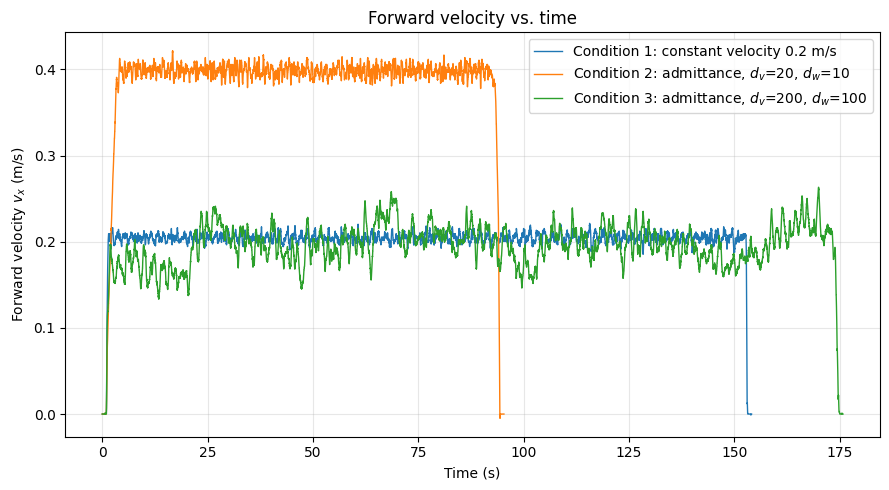

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

for cond_id, d in data.items():
    v = d["velocity"]
    ax.plot(v["t_s"], v["vx"], label=d["label"], linewidth=1)

ax.set_xlabel("Time (s)")
ax.set_ylabel(r"Forward velocity $v_x$ (m/s)")
ax.set_title("Forward velocity vs. time")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()  # inline only, no file saved to disk


## Raw $F_x$-$F_z$ point cloud

Raw handle-force point cloud, all three conditions overlaid on one axes (distinct colours,
legend), before filtering and without any tipping-boundary overlay (that belongs to the
Stability Analysis chapter). Equal aspect ratio and fixed limits so a 1 N step looks the same
on both axes and the shape stays comparable across re-runs.


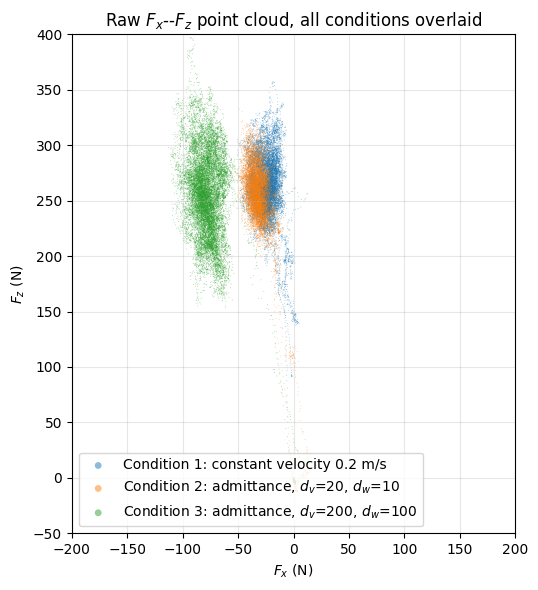

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))

for cond_id, d in data.items():
    f = d["force"]
    # small hard-edged dots, no marker edge, low alpha - keeps the ~42k overlaid
    # points individually visible instead of smearing into blobs
    ax.scatter(
        f["Fx_thesis_N"], f["Fz_total_N"],
        s=1.5, alpha=0.5, marker=".",
        linewidths=0, edgecolors="none",
        rasterized=True, label=d["label"],
    )

ax.set_xlabel(r"$F_x$ (N)")
ax.set_ylabel(r"$F_z$ (N)")
ax.set_title(r"Raw $F_x$--$F_z$ point cloud, all conditions overlaid")
ax.set_aspect("equal")          # 1:1 scaling between Fx and Fz axes
ax.set_xlim(-200, 200)
ax.set_ylim(-50, 400)
ax.legend(markerscale=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()  # inline only, no file saved to disk
